# PrÃ©diction du prix de l'immobilier â Californie
Dataset : Kaggle California Housing Prices | ModÃ¨les : LinearRegression, Ridge, Lasso

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("archive/housing.csv")
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
display(df.describe().round(2))
print("\nValeurs manquantes :")
print(df.isnull().sum())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00



Valeurs manquantes :
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


## 2. Analyse exploratoire (EDA)

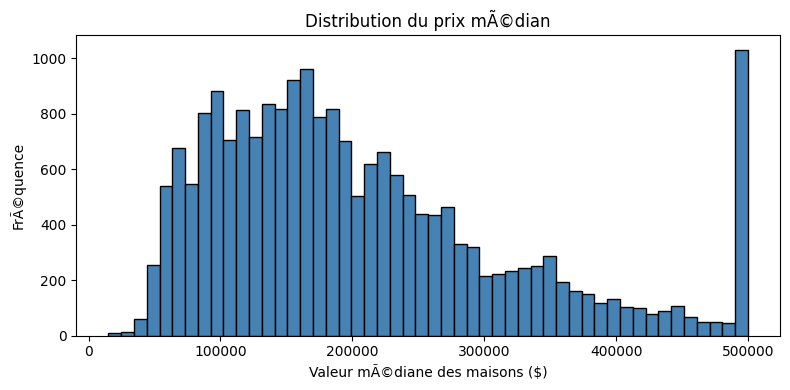

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['median_house_value'], bins=50, edgecolor='black', color='steelblue')
ax.set_xlabel('Valeur mÃ©diane des maisons ($)')
ax.set_ylabel('FrÃ©quence')
ax.set_title('Distribution du prix mÃ©dian')
plt.tight_layout()
plt.show()

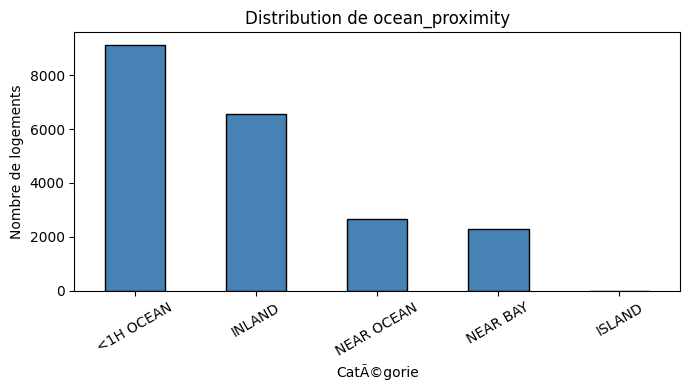

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
df['ocean_proximity'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('CatÃ©gorie')
ax.set_ylabel('Nombre de logements')
ax.set_title('Distribution de ocean_proximity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

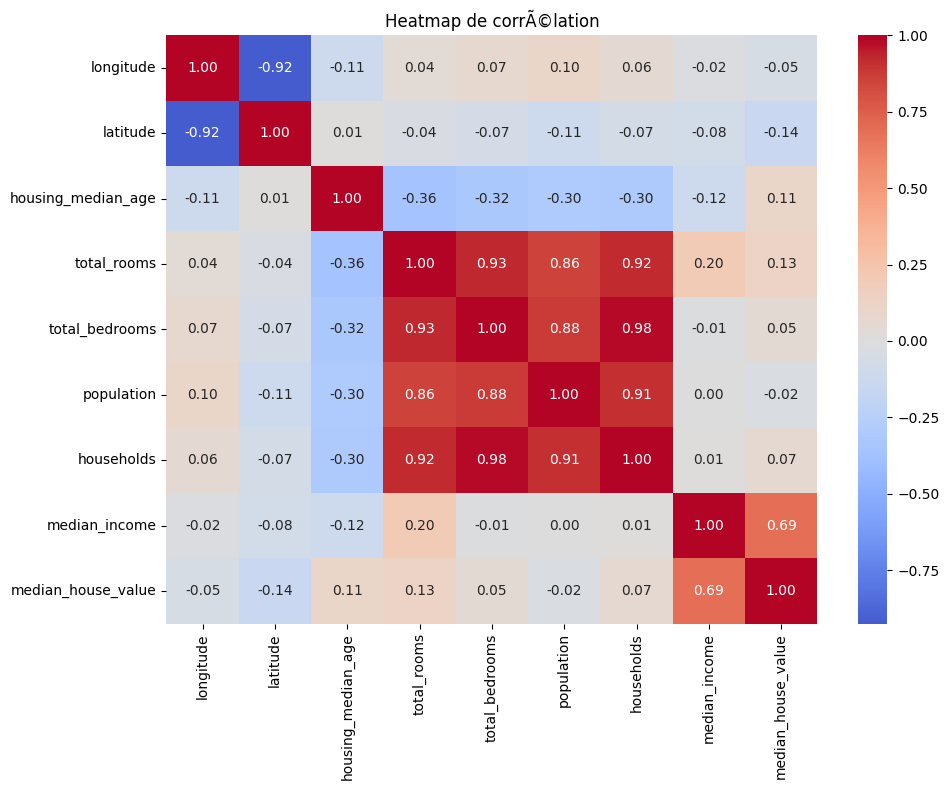

In [5]:
numeric_cols = df.select_dtypes(include='number').columns
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Heatmap de corrÃ©lation')
plt.tight_layout()
plt.show()

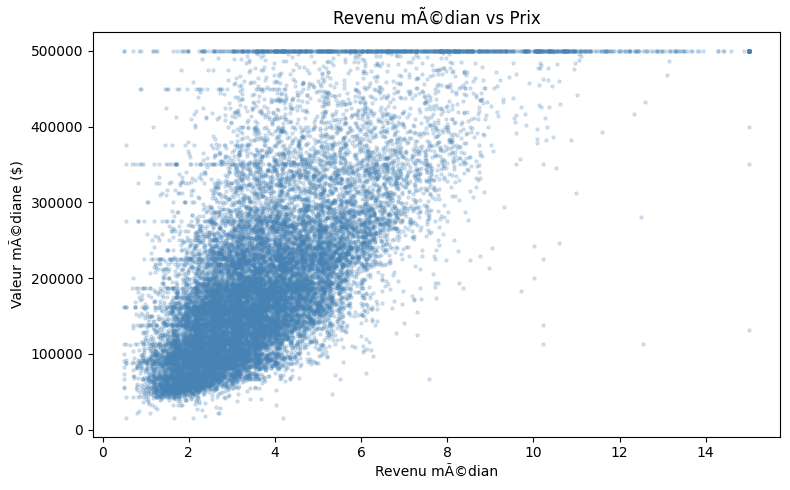

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['median_income'], df['median_house_value'], alpha=0.2, s=5, color='steelblue')
ax.set_xlabel('Revenu mÃ©dian')
ax.set_ylabel('Valeur mÃ©diane ($)')
ax.set_title('Revenu mÃ©dian vs Prix')
plt.tight_layout()
plt.show()

## 3. Nettoyage + Feature Engineering

In [7]:
# Supprimer les 5 lignes ISLAND (trop peu pour Ãªtre reprÃ©sentatives)
df = df[df['ocean_proximity'] != 'ISLAND'].copy()

# Imputer total_bedrooms avec la mÃ©diane (207 NaN)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print(f"Lignes aprÃ¨s suppression ISLAND : {len(df)}")
print(f"NaN restants : {df.isnull().sum().sum()}")

Lignes aprÃ¨s suppression ISLAND : 20635
NaN restants : 0


In [8]:
df['avg_rooms'] = df['total_rooms'] / df['households']
df['avg_bedrooms'] = df['total_bedrooms'] / df['households']
df['avg_occupancy'] = df['population'] / df['households']
df['rooms_per_bedroom'] = df['avg_rooms'] / df['avg_bedrooms']

print("Features dÃ©rivÃ©es crÃ©Ã©es :")
display(df[['avg_rooms', 'avg_bedrooms', 'avg_occupancy', 'rooms_per_bedroom']].describe().round(3))

Features dÃ©rivÃ©es crÃ©Ã©es :


,avg_rooms,avg_bedrooms,avg_occupancy,rooms_per_bedroom
count,20635.000,20635.000,20635.000,20635.000
mean,5.429,1.101,3.071,4.994
std,2.474,0.519,10.387,1.239
min,0.846,0.121,0.692,0.354
25%,4.441,1.006,2.430,4.165
50%,5.229,1.049,2.818,4.923
75%,6.052,1.100,3.282,5.707
max,141.909,34.067,1243.333,26.917


In [9]:
from sklearn.model_selection import train_test_split

# One-hot encode â rÃ©fÃ©rence (dropped) : <1H OCEAN
dummies = pd.get_dummies(df['ocean_proximity'], prefix='ocean_proximity', drop_first=True, dtype=int)
df = pd.concat([df.drop('ocean_proximity', axis=1), dummies], axis=1)

# Supprimer les totaux bruts (remplacÃ©s par les moyennes)
df = df.drop(columns=['total_rooms', 'total_bedrooms', 'households'])

feature_names = [c for c in df.columns if c != 'median_house_value']
print(f"Features finales ({len(feature_names)}) :")
for i, f in enumerate(feature_names):
    print(f"  {i}: {f}")

Features finales (12) :
  0: longitude
  1: latitude
  2: housing_median_age
  3: population
  4: median_income
  5: avg_rooms
  6: avg_bedrooms
  7: avg_occupancy
  8: rooms_per_bedroom
  9: ocean_proximity_INLAND
  10: ocean_proximity_NEAR BAY
  11: ocean_proximity_NEAR OCEAN


In [10]:
X = df[feature_names]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

Train : (16508, 12)  |  Test : (4127, 12)


## 4. ModÃ©lisation & Comparaison des modÃ¨les
Pipeline sklearn : StandardScaler â modÃ¨le. Comparaison RMSE / MAE / RÂ² sur le test set.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]),
    'Lasso': LassoCV(cv=5, random_state=42, max_iter=5000)
}

results = {}
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    results[name] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'RÂ²': round(r2, 4)}
    pipelines[name] = pipe
    print(f"{name:20s}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}  RÂ²={r2:.4f}")


LinearRegression      RMSE=$73,455  MAE=$52,377  RÂ²=0.5913
Ridge                 RMSE=$73,455  MAE=$52,376  RÂ²=0.5913


Lasso                 RMSE=$73,494  MAE=$52,338  RÂ²=0.5909


In [12]:
results_df = pd.DataFrame(results).T.sort_values('RÂ²', ascending=False)
print("\nTableau comparatif (triÃ© par RÂ² dÃ©croissant) :")
display(results_df)

best_name = results_df['RÂ²'].idxmax()
best_pipeline = pipelines[best_name]
best_metrics = results[best_name]
print(f"\nMeilleur modÃ¨le : {best_name}  (RÂ²={best_metrics['RÂ²']:.4f})")



Tableau comparatif (triÃ© par RÂ² dÃ©croissant) :


,RMSE,MAE,RÂ²
LinearRegression,73455.16,52376.91,0.5913
Ridge,73454.82,52375.66,0.5913
Lasso,73494.26,52338.25,0.5909



Meilleur modÃ¨le : LinearRegression  (RÂ²=0.5913)


## 5. Analyse des rÃ©sidus

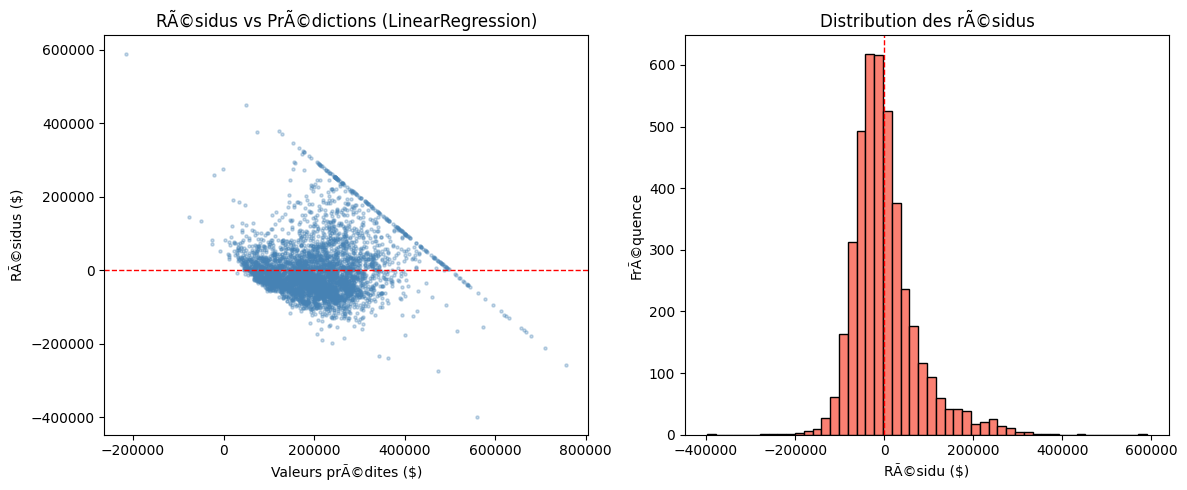

In [13]:
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Valeurs prÃ©dites ($)')
axes[0].set_ylabel('RÃ©sidus ($)')
axes[0].set_title(f'RÃ©sidus vs PrÃ©dictions ({best_name})')

axes[1].hist(residuals, bins=50, edgecolor='black', color='salmon')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('RÃ©sidu ($)')
axes[1].set_ylabel('FrÃ©quence')
axes[1].set_title('Distribution des rÃ©sidus')

plt.tight_layout()
plt.show()

In [14]:
seuil = 3 * residuals.std()
n_outliers = int((np.abs(residuals) > seuil).sum())
print(f"Seuil (3Ï = ${seuil:,.0f}) : {n_outliers} outliers / {len(residuals)} ({100*n_outliers/len(residuals):.1f}%)")

Seuil (3Ï = $220,339) : 85 outliers / 4127 (2.1%)


## 6. Export du modèle

In [15]:
import joblib
import json

# joblib (pickle) est sur ici : le .pkl est genere et charge localement,
# jamais transmis sur un reseau ni charge depuis une source externe.
joblib.dump(best_pipeline, "model.pkl")
joblib.dump(feature_names, "feature_names.pkl")  # liste de 12 noms dans l'ordre exact

json.dump(
    {
        "model_name": best_name,
        "r2": best_metrics['RÂ²'],
        "rmse": best_metrics['RMSE'],
        "mae": best_metrics['MAE']
    },
    open("metrics.json", "w")
)

print("Artefacts exportes :")
print("  model.pkl          Pipeline sklearn (StandardScaler + meilleur modele)")
print("  feature_names.pkl  Liste de 12 features")
print("  metrics.json       Metriques du test set")

Artefacts exportes :
  model.pkl          Pipeline sklearn (StandardScaler + meilleur modele)
  feature_names.pkl  Liste de 12 features
  metrics.json       Metriques du test set


In [16]:
test_pipe = joblib.load("model.pkl")
test_names = joblib.load("feature_names.pkl")
test_metrics = json.load(open("metrics.json"))

assert len(test_names) == 12, f"Attendu 12 features, obtenu {len(test_names)}"
print(f"Pipeline OK : {list(test_pipe.named_steps.keys())}")
print(f"Features ({len(test_names)}) : {test_names}")
print(f"Métriques : {test_metrics}")

Pipeline OK : ['scaler', 'model']
Features (12) : ['longitude', 'latitude', 'housing_median_age', 'population', 'median_income', 'avg_rooms', 'avg_bedrooms', 'avg_occupancy', 'rooms_per_bedroom', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Métriques : {'model_name': 'LinearRegression', 'r2': 0.5913, 'rmse': 73455.16, 'mae': 52376.91}
